## Data Loading

In [1]:
import pandas as pd
data = pd.read_csv('./healthcare-dataset-stroke-data.csv')
data

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


## Data Splitting

In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

#print(data.iloc[20])

data.fillna(0, inplace=True)

X = data.drop(['stroke'], axis=1)
y = data['stroke']

#print(X.iloc[20])
#print(y[20])

#X.index = X.gender

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

#print(X_train.iloc[20])
#print(X_test.iloc[20])
#print(y_train[0])
#print(X_train.shape)
#print(X_test.shape)
#print(y_train.shape)
#print(y_test.shape)

#X.smoking_status.value_counts()

## Feature Encoding & Transformation

In [4]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin

nominal_columns = ['work_type']
ordinal_or_binary_columns = ['Residence_type', 'gender', 'ever_married', 'smoking_status']
irrelevant_columns = ['id']

ordinal_encoder = OrdinalEncoder(categories=[
    ['Rural', 'Urban'],
    ['Male', 'Female', 'Other'],
    ['Yes', 'No'],
    ['Unknown', 'never smoked', 'formerly smoked', 'smokes']
])

feature_encoder = make_column_transformer(
    (OneHotEncoder(), nominal_columns),
    (ordinal_encoder, ordinal_or_binary_columns),
    ('drop', irrelevant_columns),
    remainder='passthrough'
)

scaler = MinMaxScaler()

class PreprocessingTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X_encoded = feature_encoder.fit_transform(X)
        scaler.fit(X_encoded)
        return self

    def transform(self, X, y=None):
        X_scaled = scaler.transform(feature_encoder.transform(X))
        # Return the 
        return pd.DataFrame(X_scaled, index=X.index)

preprocessing_pipeline = PreprocessingTransformer()
preprocessing_pipeline.fit_transform(X_train)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
2332,0.0,0.0,1.0,0.0,0.0,1.0,0.5,1.0,1.000000,0.841309,0.0,1.0,0.661112,0.437500
4347,0.0,0.0,1.0,0.0,0.0,1.0,0.5,0.0,0.333333,0.365234,0.0,0.0,0.154372,0.464139
3156,0.0,0.0,0.0,1.0,0.0,0.0,0.5,0.0,0.333333,0.353027,0.0,0.0,0.064629,0.274590
1564,0.0,0.0,1.0,0.0,0.0,0.0,0.5,0.0,0.666667,0.304199,0.0,0.0,0.063060,0.564549
12,0.0,0.0,1.0,0.0,0.0,1.0,0.5,0.0,1.000000,0.658203,0.0,0.0,0.228003,0.279713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
664,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.682617,0.0,0.0,0.120303,0.275615
3276,0.0,0.0,0.0,1.0,0.0,1.0,0.5,0.0,0.000000,0.963379,0.0,0.0,0.107100,0.327869
1318,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.333333,0.609375,0.0,1.0,0.141723,0.326844
723,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.609375,0.0,0.0,0.104007,0.250000


## Cross Validation Function

In [5]:
from sklearn.metrics import get_scorer
import numpy as np

def cross_validate_and_predict(model, X_train, y_train, metrics, cv_folds=5, random_state=1234):
    # Convert metrics to functions if they are strings
    metric_fns = [metric if callable(metric) else get_scorer(metric)._score_func for metric in metrics]
    kfold = KFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    y_preds = np.zeros(y_train.shape)
    results = []
    fold = 1
    for train_idx, test_idx in kfold.split(X_train):
        model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        y_pred = model.predict(X_train.iloc[test_idx])
        y_preds[test_idx] = y_pred
        fold_results = {'fold': fold}
        for metric_name, metric_fn in zip(metrics, metric_fns):
            value = metric_fn(y_train.iloc[test_idx], y_pred)
            fold_results[metric_name] = value
        results.append(fold_results)
        fold += 1
    return pd.DataFrame(results), y_preds

## Random Forest

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# Define scoring metrics
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'average_precision']

# Initialize KFold
k_fold = KFold(n_splits=5, random_state=1234, shuffle=True)

# Initialize Random Forest Classifier
rf_classifier = RandomForestClassifier(
    n_estimators=200,  # You can adjust this
    max_depth=10,
    min_samples_leaf=8,
    min_samples_split=2,
    random_state=1234,
    class_weight='balanced',  # Important for imbalanced datasets
    n_jobs=-1  # Use all available cores
)
# Create pipeline
rf_pipeline = make_pipeline(feature_encoder, scaler, rf_classifier)

# Cross validation and prediction
# def cross_validate_and_predict(estimator, X, y, scoring):
#     cv_results = cross_validate(estimator, X, y, cv=k_fold, scoring=scoring)
#     y_pred = cross_val_predict(estimator, X, y, cv=k_fold)
#     return cv_results, y_pred

rf_performance, rf_pred = cross_validate_and_predict(
    rf_pipeline, X_train, y_train, scoring_metrics
)

# Print results
print("Classification Report:")
print(classification_report(y_train, rf_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_train, rf_pred))

# Convert performance metrics to DataFrame for better visualization
rf_performance_df = pd.DataFrame(rf_performance)
print("\nCross-Validation Results:")
print(rf_performance_df.mean())  # Print mean of each metric across folds

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.89      0.93      3890
           1       0.19      0.53      0.28       198

    accuracy                           0.87      4088
   macro avg       0.58      0.71      0.61      4088
weighted avg       0.94      0.87      0.90      4088


Confusion Matrix:
[[3455  435]
 [  93  105]]

Cross-Validation Results:
fold                 3.000000
accuracy             0.870850
precision            0.197253
recall               0.535077
f1                   0.286631
average_precision    0.128326
dtype: float64


In [7]:
#Best Parameters: {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 8, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__n_estimators': 200}

## Oversampling with SMOTE

In [8]:
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline


string_cols = X_train.select_dtypes(include=['object']).columns
string_cols_indices = [X_train.columns.get_loc(col) for col in string_cols]

smote = SMOTENC(string_cols_indices, random_state=1234)
smote_rf_pipeline = ImbPipeline([("SMOTE", smote), ("RF", rf_pipeline)])


smote_rf_performance, smote_rf_pred = cross_validate_and_predict(
    smote_rf_pipeline, X_train, y_train, scoring_metrics
)

print(classification_report(y_train, smote_rf_pred))
print(confusion_matrix(y_train, smote_rf_pred))

smote_rf_performance

              precision    recall  f1-score   support

           0       0.97      0.81      0.88      3890
           1       0.13      0.54      0.20       198

    accuracy                           0.80      4088
   macro avg       0.55      0.67      0.54      4088
weighted avg       0.93      0.80      0.85      4088

[[3145  745]
 [  91  107]]


,fold,accuracy,precision,recall,f1,average_precision
0,1,0.803178,0.115152,0.558824,0.190955,0.082687
1,2,0.787286,0.100000,0.447368,0.163462,0.070409
2,3,0.782396,0.164021,0.607843,0.258333,0.124149
3,4,0.785802,0.117978,0.538462,0.193548,0.085558
4,5,0.818849,0.126667,0.527778,0.204301,0.087660


## Oversampling Using Random Oversampler

In [9]:
from imblearn.over_sampling import RandomOverSampler

oversampler = RandomOverSampler(sampling_strategy="minority")
oversampled_rf_pipeline = ImbPipeline([("Over Sampler", oversampler), ("RF", rf_pipeline)])

#oversampled_svm_performance = cross_val_predict(oversampled_svm_pipeline, X_train, y=y_train, cv=k_fold)

#print(classification_report(y_train, oversampled_svm_performance))
#print(confusion_matrix(y_train, oversampled_svm_performance))

X_train_resampled, y_train_resampled = oversampler.fit_resample(X_train, y_train)

print("Shape of X_train_resampled", X_train_resampled.shape)
print("Number of duplicated instances in X_train_resampled", X_train_resampled.duplicated().sum())
print("Percent of y_train_resampled that is positive class:", y_train_resampled.mean())

oversampled_rf_performance, oversampled_rf_pred = cross_validate_and_predict(
    oversampled_rf_pipeline, X_train, y_train, scoring_metrics
)

print(classification_report(y_train, oversampled_rf_pred))
print(confusion_matrix(y_train, oversampled_rf_pred))

oversampled_rf_performance

Shape of X_train_resampled (7780, 11)
Number of duplicated instances in X_train_resampled 3692
Percent of y_train_resampled that is positive class: 0.5
              precision    recall  f1-score   support

           0       0.97      0.87      0.92      3890
           1       0.18      0.55      0.27       198

    accuracy                           0.85      4088
   macro avg       0.58      0.71      0.59      4088
weighted avg       0.94      0.85      0.89      4088

[[3384  506]
 [  89  109]]


,fold,accuracy,precision,recall,f1,average_precision
0,1,0.855746,0.155738,0.558824,0.243590,0.105367
1,2,0.822738,0.125874,0.473684,0.198895,0.084074
2,3,0.845966,0.200000,0.490196,0.284091,0.129824
3,4,0.882497,0.233645,0.641026,0.342466,0.166908
4,5,0.865361,0.186441,0.611111,0.285714,0.131072


## Visualization

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_performances(named_performances):
    # Concatenate all the results DataFrames into a single dataframe
    all_performances = None
    for model_name, performance in named_performances:
        performance = performance.copy()
        # Add a column for the "model" so we know which results belong to which
        performance['model'] = model_name
        if all_performances is None:
            all_performances = performance
        else:
            all_performances = pd.concat([all_performances, performance])
    # Remove the "fold" attribute, so we don't graph it
    all_performances.drop('fold', axis=1, inplace=True)
    # Melt the data, so its in a "long" format instead of a "wide" format,
    # which seaborn prefers.
    performances_melted = all_performances.melt(id_vars=['model'], var_name='metric', value_name='score')
    
    # Use Seaborn/matplot to plot the comparative boxplots
    plt.figure(figsize=(12, 6))
    # The x-axis is the metric, the y-axis is the score, and the hue is the model
    sns.boxplot(data=performances_melted, x='metric', y='score', hue='model')
    # Always use 0-1 for the y-axis.
    plt.ylim(0, 1)
    plt.title('Model Performances')
    plt.ylabel('Score')
    plt.xticks(rotation=45)
    plt.show()

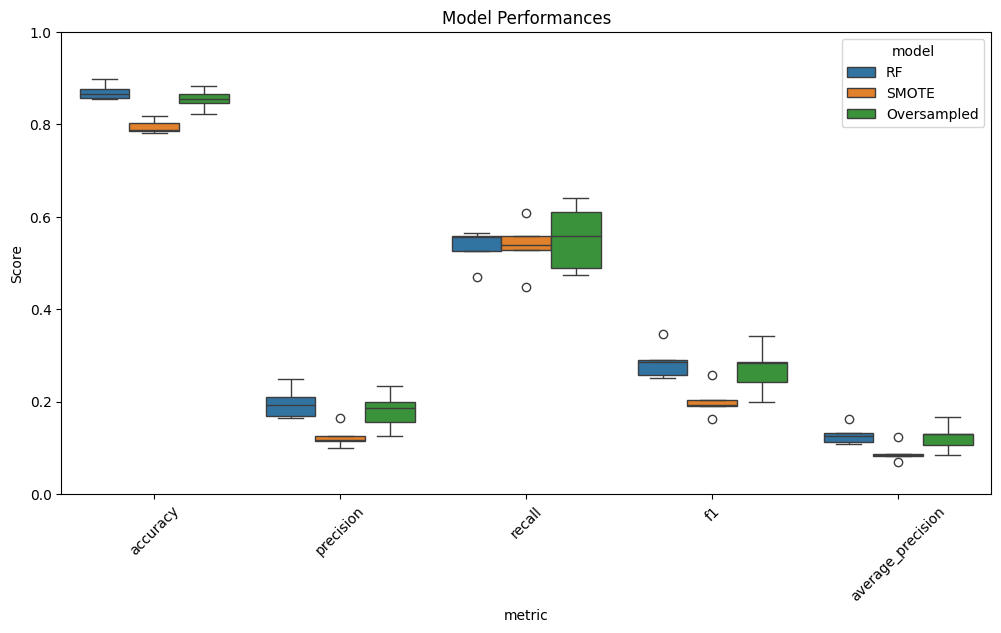

In [11]:
plot_performances([
    ('RF', rf_performance),
    ('SMOTE', smote_rf_performance),
    ('Oversampled', oversampled_rf_performance)
])

## Hyperparameter Tuning

In [12]:
print(rf_pipeline.named_steps)


{'columntransformer': ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder', OneHotEncoder(),
                                 ['work_type']),
                                ('ordinalencoder',
                                 OrdinalEncoder(categories=[['Rural', 'Urban'],
                                                            ['Male', 'Female',
                                                             'Other'],
                                                            ['Yes', 'No'],
                                                            ['Unknown',
                                                             'never smoked',
                                                             'formerly smoked',
                                                             'smokes']]),
                                 ['Residence_type', 'gender', 'ever_married',
                                  'smoking_status']),
                            

In [13]:
param_grid = {
    'randomforestclassifier__n_estimators': [100, 200, 300, 400, 500],
    'randomforestclassifier__max_depth': [None, 10, 20, 30, 40],
    'randomforestclassifier__min_samples_split': [2, 5, 10, 12, 16],
    'randomforestclassifier__min_samples_leaf': [1, 2, 4, 6, 8]
}

In [23]:
from sklearn.metrics import fbeta_score, make_scorer

In [24]:
from sklearn.model_selection import GridSearchCV
ftwo_scorer = make_scorer(fbeta_score, beta=2)

grid_search = GridSearchCV(
    rf_pipeline, param_grid, cv=10, scoring=ftwo_scorer, n_jobs=-1, verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)


Fitting 10 folds for each of 625 candidates, totalling 6250 fits
Best Parameters: {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 8, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__n_estimators': 200}


## Test Prediction

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score
import pandas as pd

def evaluate_pipelines_holdout(pipelines, X_train, y_train, X_evaluate, y_evaluate):
    rows = []
    for name, pipeline in pipelines:
        pipeline.fit(X_train, y_train)
        test_predictions = pipeline.predict(X_evaluate)
        row = {'name': name}
        
        for metric in [accuracy_score, precision_score, recall_score, f1_score]:
            metric_name = metric.__name__
            row[f'eval_{metric_name}'] = metric(y_evaluate, test_predictions)
        
        # Adding F2-score
        row['eval_fbeta_score_2'] = fbeta_score(y_evaluate, test_predictions, beta=2)
        
        rows.append(row)
    return pd.DataFrame(rows)


In [21]:
# This makes it easier to get the values we calculated earlier
evaluate_pipelines_holdout([('rf_oversampled', oversampled_rf_pipeline)], X_train, y_train, X_test, y_test)

,name,eval_accuracy_score,eval_precision_score,eval_recall_score,eval_f1_score,eval_fbeta_score_2
0,rf_oversampled,0.8591,0.203822,0.627451,0.307692,0.443213


In [22]:
# First fit the pipeline on your training data
oversampled_rf_pipeline.fit(X_train, y_train)

# Make predictions on the test data
y_pred_test = oversampled_rf_pipeline.predict(X_test)

# Generate and print the classification report
print("Test Set Classification Report:")
print(classification_report(y_test, y_pred_test))

# Optional: Print confusion matrix
print("\nTest Set Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

# Optional: Get probability scores for the positive class (useful for ROC/AUC)
y_pred_proba = oversampled_rf_pipeline.predict_proba(X_test)[:, 1]

# Optional: Calculate ROC AUC score
from sklearn.metrics import roc_auc_score
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.87      0.92       971
           1       0.21      0.65      0.32        51

    accuracy                           0.86      1022
   macro avg       0.60      0.76      0.62      1022
weighted avg       0.94      0.86      0.89      1022


Test Set Confusion Matrix:
[[848 123]
 [ 18  33]]

ROC AUC Score: 0.8282
